# Gemini: Aspect Identification & Extraction Pipeline
This notebook runs general and specific aspect identification and aspect extraction pipelines, then generates validation results and visualizations.

Sections added below:
- Aspect Identification
  - General Aspects
  - Specific Aspects
- Aspect Extraction
- Visualization Generation

In [1]:
import base64
import os
from pathlib import Path
from dotenv import load_dotenv
from gemini import generate, TaskType
import time

# Load environment variables
load_dotenv()

True

## Aspect Identification
This section contains code to identify general and specific aspects. The following cells set paths and run the general identification step and validation.

In [ ]:
# Configure file paths
IDENTIFIER_FILES = Path('d:/DLSU/THESIS/Aspect-Extraction-On-Shopee-Reviews/geminiAPI/aspect_identification')

# Files for General Aspect Identification
GEN_IDENTIFICATION_FILES = {
    'gen-example': IDENTIFIER_FILES / 'multi-gen-examples.csv',
    'gen-test': IDENTIFIER_FILES / 'review-only-test.csv',
    'gen-output': IDENTIFIER_FILES / 'final_predicted.csv'
}

### General Aspects — run and validate
The next code cell runs the general aspect identification model (LLM) using provided example and test files. The following validation cell runs `validate_all_aspects` to compute exact match accuracy, hamming loss, and F1 metrics for the general aspects.

In [ ]:
# Run Aspect Identification
print("=== Starting General Aspect Identification ===")
generate(
    TaskType.IDENTIFY_GENERAL,
    example_file=GEN_IDENTIFICATION_FILES['gen-example'],
    test_file=GEN_IDENTIFICATION_FILES['gen-test'],
    output_file=GEN_IDENTIFICATION_FILES['gen-output']
)
print("\n=== General Aspect Identification Complete ===")

#### Description: Running general identification and validation
- `generate(TaskType.IDENTIFY_GENERAL, ...)` runs the general aspect identification LLM pipeline using the example and test files.
- `validate_all_aspects(...)` computes the metrics and writes validation and error-analysis outputs.

These steps produce `final_predicted.csv`, `general_validation_results.txt`, and `general_error_analysis.txt` (files under the `aspect_identification` folder).

In [6]:
# Validate results
ASPECTS = ['product', 'delivery', 'price', 'service']

print("\n=== Starting Validation ===")
from aspect_identification.validate_multiGen import validate_all_aspects
pred_file = GEN_IDENTIFICATION_FILES['gen-output']
gt_file = IDENTIFIER_FILES / "valid_multiGen.csv"
valid_results_file = IDENTIFIER_FILES / 'general_validation_results.txt'
error_analysis_file = IDENTIFIER_FILES / 'general_error_analysis.txt'

results = validate_all_aspects(pred_file, gt_file, ASPECTS,
                         valid_results_file, error_analysis_file)

print("\n=== Validation Complete ===")


=== Starting Validation ===
Predicted data shape: (23, 5)
Ground truth data shape: (23, 5)

=== PRODUCT ASPECT ===
Accuracy: 0.8261

=== DELIVERY ASPECT ===
Accuracy: 0.9130

=== PRICE ASPECT ===
Accuracy: 0.9565

=== SERVICE ASPECT ===
Accuracy: 1.0000

Results saved to d:\DLSU\THESIS\Aspect-Extraction-On-Shopee-Reviews\geminiAPI\aspect_identification\general_validation_results.txt

Error analysis has been saved to d:\DLSU\THESIS\Aspect-Extraction-On-Shopee-Reviews\geminiAPI\aspect_identification\general_error_analysis.txt

=== Validation Complete ===


### Specific Aspects — identification & validation
The following cells run specific-aspect identification for each general aspect (product, delivery, price, service). Each block configures example files, test files, and output paths for specific-aspect models. After each prediction, validation is run and error analysis files are written (see `validation-results` and `error-analysis` folders).

In [3]:
SPECIFIC_IDENTIFY_FILES = Path('d:/DLSU/THESIS/Aspect-Extraction-On-Shopee-Reviews/geminiAPI/annotations/BTK_annotations/specific_aspect_identification')

SP_EXAMPLE_FILES = {
    'proSP-example': SPECIFIC_IDENTIFY_FILES / 'proSP-examples.csv',  # for product aspect extraction
    'delSP-example': SPECIFIC_IDENTIFY_FILES / 'delSP-examples.csv',   # for delivery aspect extraction
    'priSP-example': SPECIFIC_IDENTIFY_FILES / 'priSP-examples.csv',   # for price aspect extraction
    'serSP-example': SPECIFIC_IDENTIFY_FILES / 'serSP-examples.csv'   # for service aspect extraction
}

In [ ]:
sp_identify_config = {
        'product': {
            'task_type': TaskType.IDENTIFY_PRODUCT_SPECIFIC,
            'example_file': SP_EXAMPLE_FILES['proSP-example'],
            'test_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-pro-test.csv',
            'output_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-pro-pred.csv'
        },
        'delivery': {
            'task_type': TaskType.IDENTIFY_DELIVERY_SPECIFIC,
            'example_file': SP_EXAMPLE_FILES['delSP-example'],
            'test_file': IDENTIFIER_FILES / 'sp-del-test.csv',
            'output_file': IDENTIFIER_FILES / 'sp-del-pred.csv'
        },
        'price': {
            'task_type': TaskType.IDENTIFY_PRICE_SPECIFIC,
            'example_file': SP_EXAMPLE_FILES['priSP-example'],
            'test_file': IDENTIFIER_FILES / 'sp-pri-test.csv',
            'output_file': IDENTIFIER_FILES / 'sp-pri-pred.csv'
        },
        'service': {
            'task_type': TaskType.IDENTIFY_SERVICE_SPECIFIC,
            'example_file': SP_EXAMPLE_FILES['serSP-example'],
            'test_file': IDENTIFIER_FILES / 'sp-ser-test.csv',
            'output_file': IDENTIFIER_FILES / 'sp-ser-pred.csv'
        }
    }
# Run Specific Aspect Identification for one file/batch
# print("=== Starting Delivery Aspect Identification ===")
# generate(
#     TaskType.IDENTIFY_DELIVERY_SPECIFIC,
#     example_file=SP_EXAMPLE_FILES['delSP-example'],
#     test_file=IDENTIFIER_FILES / 'specific-aspects' / 'sp-del-test.csv',
#     output_file=IDENTIFIER_FILES / 'specific-aspects' / 'sp-del-pred.csv'
# )
# print("\n=== Delivery Aspect Identification Complete ===")

=== Starting Delivery Aspect Identification ===
Review,condition,correctness,timeliness,general
d po maganda naman po yung neck fan pero po napaka tagal po sya dumating dec9 po dec 23 napo sya dumating chaka po pink po inorder ko bakit po white yung dumating pero konti lang po yung hangin thank you po driver at seller,0,1,1,0
wrong color  design sana kung di na available yung black mag message namn kayo if ano available desisyon yarrrnnn kakainis ganitong seller,0,1,0,0
wrong color po yung dumating tapos yung green natanggal yung cover niya,0,1,0,0
sabe q ky seller mga mahaba ang ipadala nya pagdating sakin isa ang mahaba kulay biege lang panu pa masusuot ng omorder skin e ang iiksi,0,1,0,0
close to ok lang i contacted the seller and they admitted that they intentionaly sent the wrong color without informing me the problem is i ordered it as gift for a man so purple is not really ok and both bottles have scratches doesnt look new for me,0,1,0,0
5 mystery box binili ko pero 5 din na mag

In [ ]:
# Run Aspect Identification for multiple files/batches of product specific aspect
SPECIFIC_PRO_DIR = Path('d:/DLSU/THESIS/Aspect-Extraction-On-Shopee-Reviews/geminiAPI/annotations/BTK_annotations/specific_aspect_identification/product_identify')

# for i in range(1, 5):
#     print(f"=== Starting Product Specific Aspect Identification Batch {i} ===")

#     test_file = SPECIFIC_PRO_DIR / f"proSP-retry{i}.csv"
#     output_file = SPECIFIC_PRO_DIR / f"proSP-2ndtry{i}.csv"

#     generate(
#         TaskType.IDENTIFY_PRODUCT_SPECIFIC,
#         example_file=SP_EXAMPLE_FILES['proSP-example'],
#         test_file=test_file,
#         output_file=output_file
#     )
#     print(f"✓ Batch {i} complete - saved to {output_file}")

#     if i < 4:
#         print(f"⏳ Waiting 6 seconds before next batch...")
#         time.sleep(6)

print("\n=== Product Specific Aspect Identification Complete ===")

In [ ]:
# Run Aspect Identification for multiple files/batches of delivery specific aspect
SPECIFIC_DEL_DIR = Path('d:/DLSU/THESIS/Aspect-Extraction-On-Shopee-Reviews/geminiAPI/annotations/BTK_annotations/specific_aspect_identification/delivery_identify')

for i in range(1, 2):
    print(f"=== Starting Delivery Specific Aspect Identification Batch {i} ===")

    test_file = SPECIFIC_DEL_DIR / f"delSP-retry{i}.csv"
    output_file = SPECIFIC_DEL_DIR / f"delSP-2ndtry{i}.csv"
    
    generate(
        TaskType.IDENTIFY_DELIVERY_SPECIFIC,
        example_file=SP_EXAMPLE_FILES['delSP-example'],
        test_file=test_file,
        output_file=output_file
    )
    print(f"✓ Batch {i} complete - saved to {output_file}")

    # if i < 5:
    #     print(f"⏳ Waiting 6 seconds before next batch...")
    #     time.sleep(6)

print("\n=== Delivery Specific Aspect Identification Complete ===")

In [ ]:
# Run Aspect Identification for multiple files/batches of price specific aspect
SPECIFIC_PRI_DIR = Path('d:/DLSU/THESIS/Aspect-Extraction-On-Shopee-Reviews/geminiAPI/annotations/BTK_annotations/specific_aspect_identification/price_identify')

for i in range(1, 9):
    print(f"=== Starting Price Specific Aspect Identification Batch {i} ===")

    test_file = SPECIFIC_PRI_DIR / f"{i}.csv"
    output_file = SPECIFIC_PRI_DIR / f"priSP-output{i}.csv"

    generate(
        TaskType.IDENTIFY_PRICE_SPECIFIC,
        example_file=SP_EXAMPLE_FILES['priSP-example'],
        test_file=test_file,
        output_file=output_file
    )
    print(f"✓ Batch {i} complete - saved to {output_file}")

    if i < 8:
        print(f"⏳ Waiting 6 seconds before next batch...")
        time.sleep(6)

print("\n=== Price Specific Aspect Identification Complete ===")

In [ ]:
# Run Aspect Identification for multiple files/batches of service specific aspect
SPECIFIC_SER_DIR = Path('d:/DLSU/THESIS/Aspect-Extraction-On-Shopee-Reviews/geminiAPI/annotations/BTK_annotations/specific_aspect_identification/service_identify')

for i in range(1, 2):
    print(f"=== Starting Service Specific Aspect Identification Batch {i} ===")

    test_file = SPECIFIC_SER_DIR / f"serSP-5thtry{i}.csv"
    output_file = SPECIFIC_SER_DIR / f"5thtry{i}.csv"

    generate(
        TaskType.IDENTIFY_SERVICE_SPECIFIC,
        example_file=SP_EXAMPLE_FILES['serSP-example'],
        test_file=test_file,
        output_file=output_file
    )
    print(f"✓ Batch {i} complete - saved to {output_file}")

    # if i < 2:
    #     print(f"⏳ Waiting 6 seconds before next batch...")
    #     time.sleep(6)
print("\n=== Service Specific Aspect Identification Complete ===")

In [8]:
# Validate results
# specific: product
PRO_ASPECTS = ['color', 'condition', 'correctness', 'durability', 'effectiveness', 'functionality', 'material', 'sensory', 'measurement', 'general']
# specific: delivery
DEL_ASPECTS = ['condition', 'correctness', 'timeliness', 'general']
# specific: price
PRI_ASPECTS = ['affordability', 'value_for_money', 'general']
# specific: service
SER_ASPECTS = ['handling', 'responsiveness', 'trustworthiness', 'general']

validation_config = {
        'product': {
            'aspects': PRO_ASPECTS,
            'pred_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-pro-pred.csv',
            'gt_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-pro-gt.csv',
            'valid_results_file': IDENTIFIER_FILES / 'validation-results' / 'product_validation_results.txt',
            'error_results_file': IDENTIFIER_FILES / 'error-analysis' / 'product_error_analysis.txt'
        },
        'delivery': {
            'aspects': DEL_ASPECTS,
            'pred_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-del-pred.csv',
            'gt_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-del-gt.csv',
            'valid_results_file': IDENTIFIER_FILES / 'validation-results' / 'delivery_validation_results.txt',
            'error_results_file': IDENTIFIER_FILES / 'error-analysis' / 'delivery_error_analysis.txt'
        },
        'price': {
            'aspects': PRI_ASPECTS,
            'pred_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-pri-pred.csv',
            'gt_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-pri-gt.csv',
            'valid_results_file': IDENTIFIER_FILES / 'validation-results' / 'price_validation_results.txt',
            'error_results_file': IDENTIFIER_FILES / 'error-analysis' / 'price_error_analysis.txt'
        },
        'service': {
            'aspects': SER_ASPECTS,
            'pred_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-ser-pred.csv',
            'gt_file': IDENTIFIER_FILES / 'specific-aspects' / 'sp-ser-gt.csv',
            'valid_results_file': IDENTIFIER_FILES / 'validation-results' / 'service_validation_results.txt',
            'error_results_file': IDENTIFIER_FILES / 'error-analysis' / 'service_error_analysis.txt'
        }
    }

print("\n=== Starting Validation ===")
from aspect_identification.validate_multiGen import validate_all_aspects
for aspect, config in validation_config.items():
    ASPECTS = config['aspects']
    pred_file = config['pred_file']
    gt_file = config['gt_file']
    valid_results_file = config['valid_results_file']
    error_analysis_file = config['error_results_file']

    results = validate_all_aspects(pred_file, gt_file, ASPECTS,
                            valid_results_file, error_analysis_file)

print("\n=== Validation Complete ===")


=== Starting Validation ===
Predicted data shape: (16, 11)
Ground truth data shape: (16, 11)

=== COLOR ASPECT ===
Accuracy: 0.8750

=== CONDITION ASPECT ===
Accuracy: 0.7500

=== CORRECTNESS ASPECT ===
Accuracy: 0.8750

=== DURABILITY ASPECT ===
Accuracy: 1.0000

=== EFFECTIVENESS ASPECT ===
Accuracy: 0.9375

=== FUNCTIONALITY ASPECT ===
Accuracy: 0.8125

=== MATERIAL ASPECT ===
Accuracy: 1.0000

=== SENSORY ASPECT ===
Accuracy: 1.0000

=== MEASUREMENT ASPECT ===
Accuracy: 0.9375

=== GENERAL ASPECT ===
Accuracy: 0.8125

Results saved to d:\DLSU\THESIS\Aspect-Extraction-On-Shopee-Reviews\geminiAPI\aspect_identification\validation-results\product_validation_results.txt

Error analysis has been saved to d:\DLSU\THESIS\Aspect-Extraction-On-Shopee-Reviews\geminiAPI\aspect_identification\error-analysis\product_error_analysis.txt
Predicted data shape: (10, 5)
Ground truth data shape: (10, 5)

=== CONDITION ASPECT ===
Accuracy: 1.0000

=== CORRECTNESS ASPECT ===
Accuracy: 1.0000

=== TIMELI

d:\DLSU\THESIS\Aspect-Extraction-On-Shopee-Reviews\geminiAPI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\DLSU\THESIS\Aspect-Extraction-On-Shopee-Reviews\geminiAPI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\DLSU\THESIS\Aspect-Extraction-On-Shopee-Reviews\geminiAPI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_divisio

In [3]:
from aspect_identification.validate_multiGen import calculate_overall_performance, save_overall_results

general_aspect_mapping = {
    'product': ['color', 'condition', 'correctness', 'durability', 'effectiveness', 'functionality', 'material', 'sensory', 'measurement', 'general'],
    'delivery': ['condition', 'correctness', 'timeliness', 'general'],
    'price': ['affordability', 'value_for_money', 'general'],
    'service': ['handling', 'responsiveness', 'trustworthiness', 'general']
}

error_analysis_files = {
    'product': IDENTIFIER_FILES / 'error-analysis' / 'product_error_analysis.txt',
    'delivery': IDENTIFIER_FILES / 'error-analysis' / 'delivery_error_analysis.txt',
    'price': IDENTIFIER_FILES / 'error-analysis' / 'price_error_analysis.txt',
    'service': IDENTIFIER_FILES / 'error-analysis' / 'service_error_analysis.txt',
}

results = calculate_overall_performance(general_aspect_mapping, error_analysis_files)
save_overall_results(results, IDENTIFIER_FILES / 'overall_performance.txt')

Overall results saved to d:\DLSU\THESIS\Aspect-Extraction-On-Shopee-Reviews\geminiAPI\aspect_identification\overall_performance.txt


## Aspect Extraction
This section runs aspect extraction models (product, delivery, price, service). Use the example and test files defined above to extract phrases/mentions from reviews. Extraction outputs are saved under the `aspect_extraction` folder.

In [ ]:
# Files for General Aspect Extraction
EXTRACTOR_FILES = Path('d:/DLSU/THESIS/Aspect-Extraction-On-Shopee-Reviews/geminiAPI/aspect_extraction')

EXTRACTION_FILES = {
    'prod-example': EXTRACTOR_FILES / 'product-examples.json',  # for product aspect extraction
    'prod-test': EXTRACTOR_FILES / 'product-test.csv',
    'prod-output': EXTRACTOR_FILES / 'product-predicted.json',
    'del-example': EXTRACTOR_FILES / 'delivery-examples.json',   # for delivery aspect extraction
    'del-test': EXTRACTOR_FILES / 'delivery-test.csv',
    'del-output': EXTRACTOR_FILES / 'delivery-predicted.csv',
    'pri-example': EXTRACTOR_FILES / 'price-examples.json',   # for price aspect extraction
    'pri-test': EXTRACTOR_FILES / 'price-test.csv',
    'pri-output': EXTRACTOR_FILES / 'price-predicted.json',
    'ser-example': EXTRACTOR_FILES / 'service-examples.json',   # for service aspect extraction
    'ser-test': EXTRACTOR_FILES / 'service-test.csv',
    'ser-output': EXTRACTOR_FILES / 'service-predicted.json'
}

In [ ]:
# Run Product Aspect Extraction (when needed)
def run_extraction():
    extraction_config = {
        'product': {
            'task_type': TaskType.EXTRACT_PRODUCT,
            'example_file': EXTRACTION_FILES['prod-example'],
            'test_file': EXTRACTION_FILES['prod-test'],
            'output_file': EXTRACTION_FILES['prod-output']
        }
        # 'delivery': {
        #     'task_type': TaskType.EXTRACT_DELIVERY,
        #     'example_file': EXTRACTION_FILES['deliv-example'],
        #     'test_file': EXTRACTION_FILES['deliv-test'],
        #     'output_file': EXTRACTION_FILES['deliv-output']
        # },
        # 'price': {
        #     'task_type': TaskType.EXTRACT_PRICE,
        #     'example_file': EXTRACTION_FILES['pri-example'],
        #     'test_file': EXTRACTION_FILES['pri-test'],
        #     'output_file': EXTRACTION_FILES['pri-output']
        # },
        # 'service': {
        #     'task_type': TaskType.EXTRACT_SERVICE,
        #     'example_file': EXTRACTION_FILES['ser-example'],
        #     'test_file': EXTRACTION_FILES['ser-test'],
        #     'output_file': EXTRACTION_FILES['ser-output']
        # }
    }

    print(f"=== Starting {aspect.upper()} Aspect Extraction ===")
    for aspect, config in extraction_config.items():
        print(f"\n--- Extracting {aspect.upper()} Aspects ---")
        generate(
            config['task_type'],
            example_file=config['example_file'],
            test_file=config['test_file'],
            output_file=config['output_file']
        )
        print(f"--- {aspect.upper()} Extraction Complete ---")
    print(f"\n=== {aspect.upper()} Aspect Extraction Complete ===")

# Uncomment to run extraction
run_extraction()

In [ ]:
# Run Delivery Aspect Extraction for delivery aspect only
def run_extraction():
    print("=== Starting Delivery Aspect Extraction ===")
    generate(
        TaskType.EXTRACT_DELIVERY,
        example_file=EXTRACTION_FILES['del-example'],
        test_file=EXTRACTION_FILES['del-test'],
        output_file=EXTRACTION_FILES['del-output']
    )
    print("\n=== Delivery Aspect Extraction Complete ===")

# Uncomment to run extraction
# run_extraction()

In [ ]:
# Run Price Aspect Extraction for price aspect only
def run_extraction():
    print("=== Starting Price Aspect Extraction ===")
    generate(
        TaskType.EXTRACT_PRICE,
        example_file=EXTRACTION_FILES['pri-example'],
        test_file=EXTRACTION_FILES['pri-test'],
        output_file=EXTRACTION_FILES['pri-output']
    )
    print("\n=== Price Aspect Extraction Complete ===")

# Uncomment to run extraction
run_extraction()

In [ ]:
# Run Service Aspect Extraction for service aspect only
def run_extraction():
    print("=== Starting Service Aspect Extraction ===")
    generate(
        TaskType.EXTRACT_SERVICE,
        example_file=EXTRACTION_FILES['ser-example'],
        test_file=EXTRACTION_FILES['ser-test'],
        output_file=EXTRACTION_FILES['ser-output']
    )
    print("\n=== Service Aspect Extraction Complete ===")

# Uncomment to run extraction
run_extraction()

In [ ]:
# Validate extractions
print("\n=== Starting Extraction Validation ===")
from aspect_extraction.extractor_validation import validate_extractions, save_results
predicted = EXTRACTION_FILES['pri-output']
ground_truth = EXTRACTOR_FILES / "price-valid.json"
results = validate_extractions(predicted, ground_truth)
print(f"Average F1 Score: {results['average_f1']:.3f}")
print(f"Total reviews: {results['total_reviews']}")
print(f"Missing reviews: {results['missing_reviews']}")
print("\n=== Extraction Validation Complete ===")
# save_results(results, EXTRACTOR_FILES / "product_validation_results.txt")
# save_results(results, EXTRACTOR_FILES / "delivery_validation_results.txt")
save_results(results, EXTRACTOR_FILES / "price_validation_results.txt")
# save_results(results, EXTRACTOR_FILES / "service_validation_results.txt")

In [6]:
from aspect_extraction.extractor_validation import load_results_from_txt, extraction_error_analysis, save_error_analysis

error_analysis_results = extraction_error_analysis(load_results_from_txt(EXTRACTOR_FILES / "validation_results" / "service_validation_results.txt"))
save_error_analysis(error_analysis_results, EXTRACTOR_FILES / "error_analysis" / "service_error_analysis_results.txt")

Error analysis has been saved to d:\DLSU\THESIS\Aspect-Extraction-On-Shopee-Reviews\geminiAPI\aspect_extraction\error_analysis\service_error_analysis_results.txt


## Visualization Generation
This section creates visualizations from validation outputs: confusion matrices (TP/FP/TN/FN labeled) and grouped bar charts comparing techniques across metrics (exact match accuracy, hamming loss, micro/macro F1). Run the visualization cells to display figures for each general aspect and for comparative technique-level charts.

Note: the visualizations use the aggregated `overall_performance` data and the per-aspect metrics defined below. Do not modify code cells—only run them to view the plots.

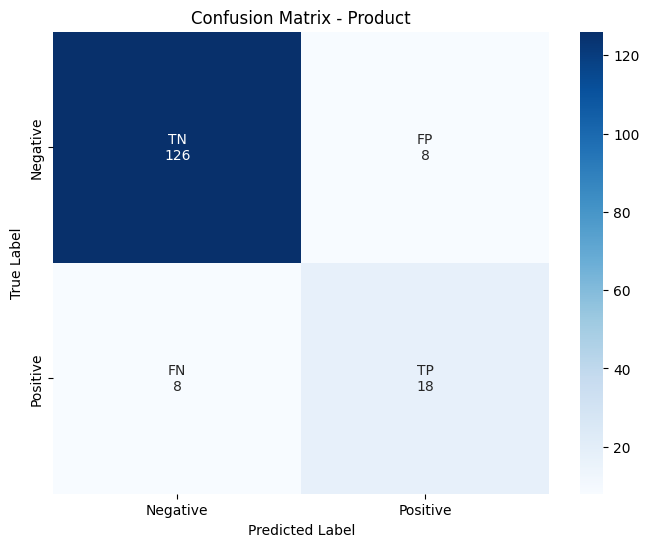

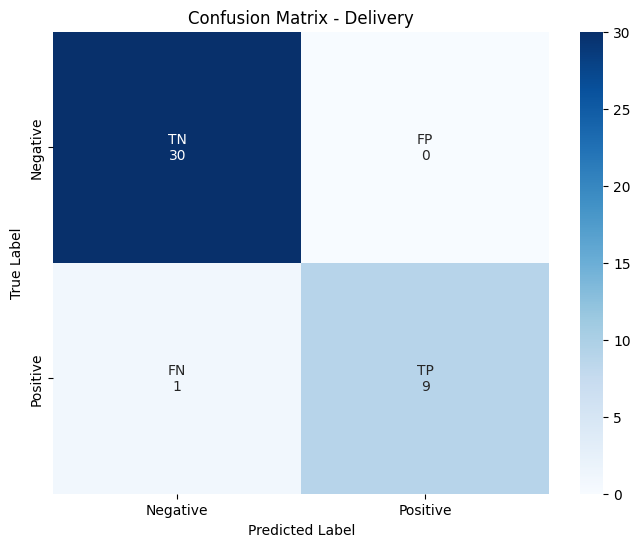

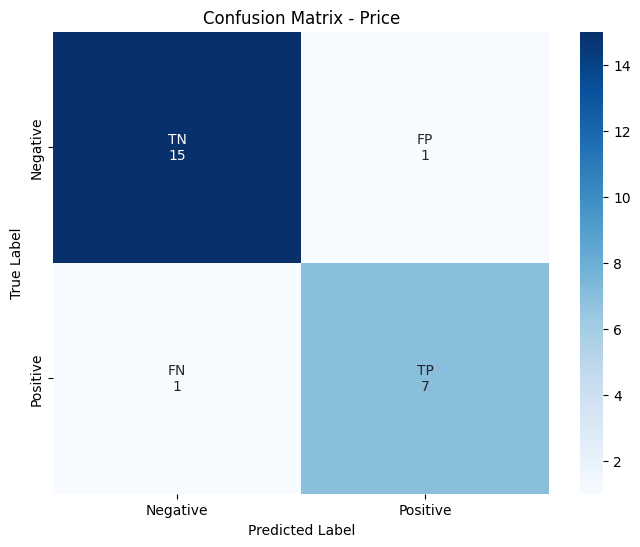

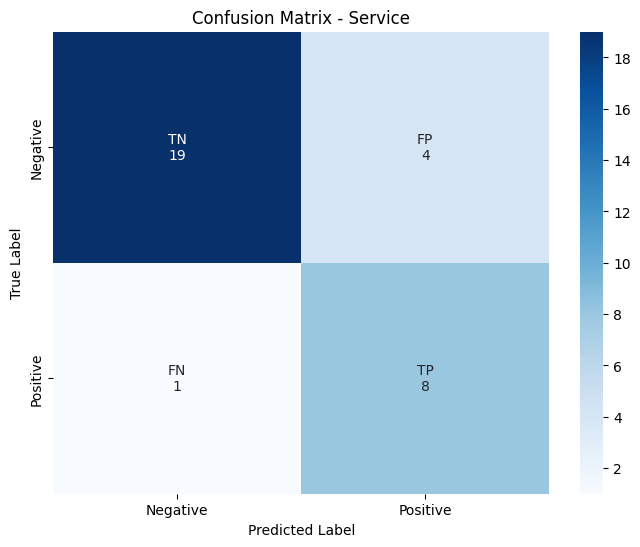

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(tp, fp, tn, fn, title):
    # Create the confusion matrix with labels
    labels = np.array([[f'TN\n{tn}', f'FP\n{fp}'],
                      [f'FN\n{fn}', f'TP\n{tp}']])
    
    # Create numerical matrix for colors
    cm = np.array([[tn, fp],
                  [fn, tp]])
    
    # Create a figure and axis with larger size
    plt.figure(figsize=(8, 6))
    
    # Create heatmap with labels
    ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                     xticklabels=['Negative', 'Positive'],
                     yticklabels=['Negative', 'Positive'])
    
    # Customize the plot
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Center the annotations
    for t in ax.texts:
        t.set_horizontalalignment('center')
    
    plt.show()

# Plot confusion matrix for each general aspect
aspect_metrics = {
    'Product': {'tp': 18, 'fp': 8, 'tn': 126, 'fn': 8},
    'Delivery': {'tp': 9, 'fp': 0, 'tn': 30, 'fn': 1},
    'Price': {'tp': 7, 'fp': 1, 'tn': 15, 'fn': 1},
    'Service': {'tp': 8, 'fp': 4, 'tn': 19, 'fn': 1}
}

for aspect, metrics in aspect_metrics.items():
    plot_confusion_matrix(
        metrics['tp'], metrics['fp'], 
        metrics['tn'], metrics['fn'], 
        aspect
    )

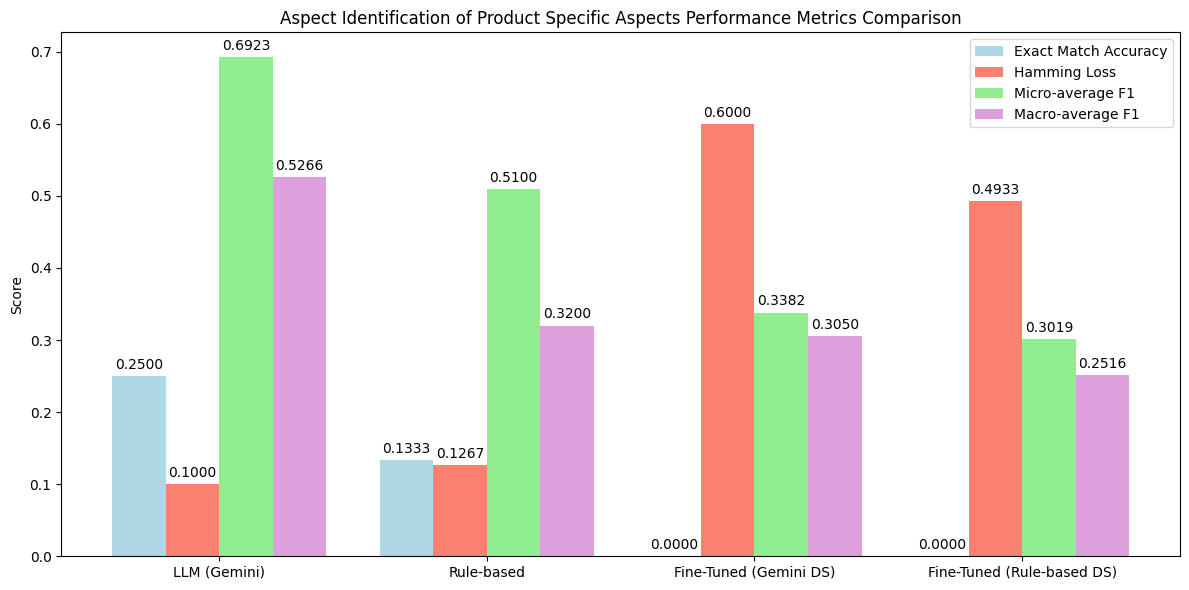

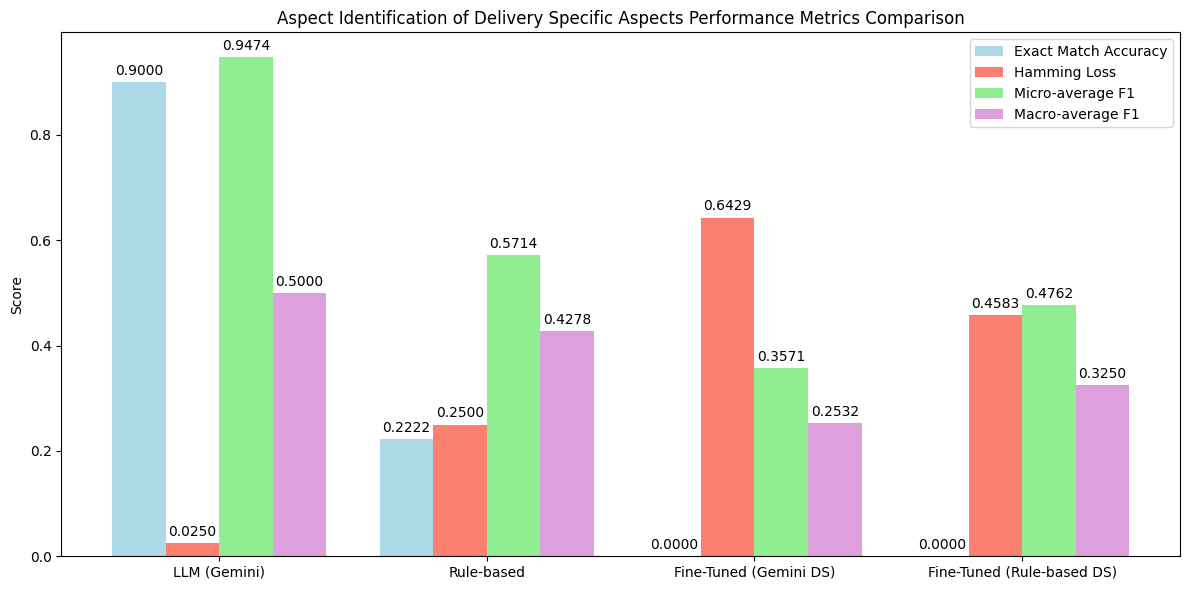

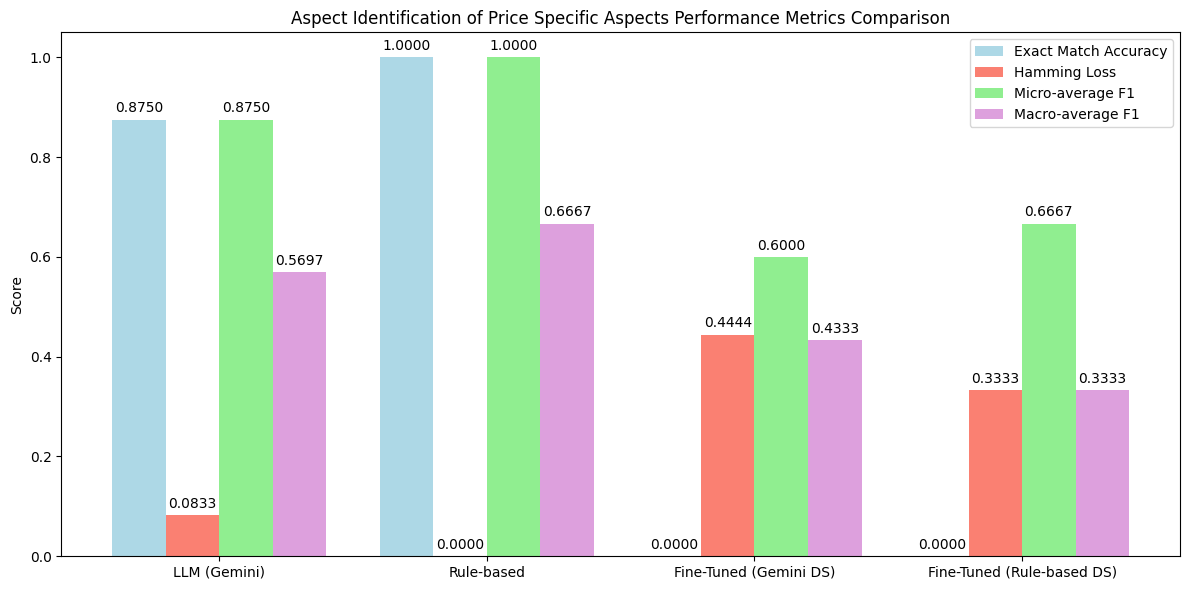

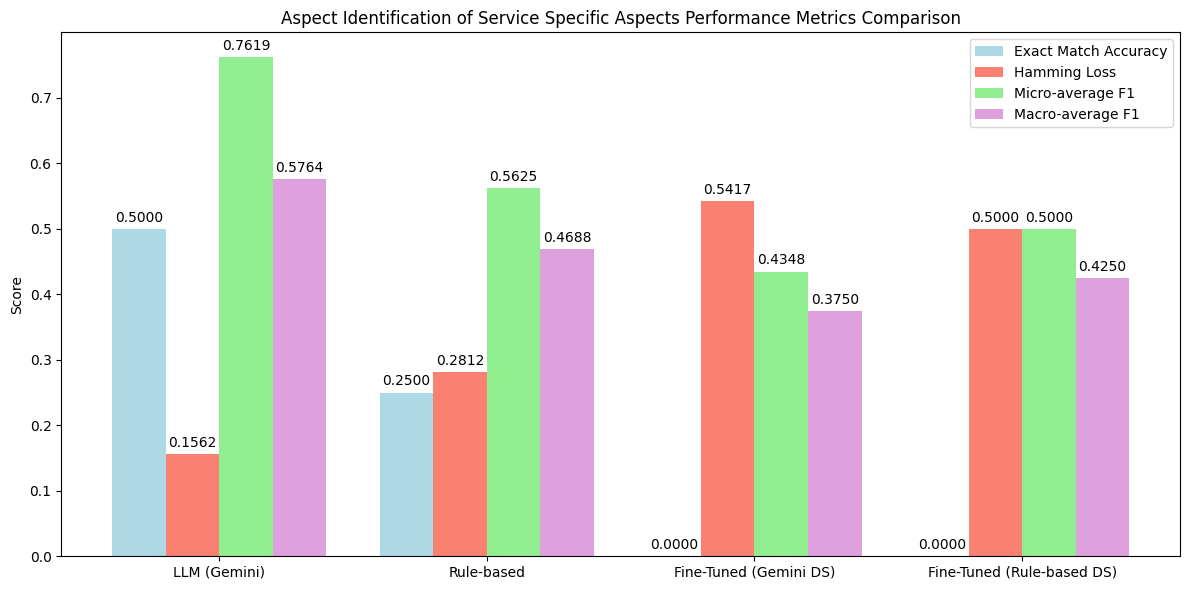

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_metrics_bar_charts(metrics_dict, aspects, techniques):
    """
    Plot bar charts for all metrics across all aspects and techniques.
    metrics_dict: dict of dicts, e.g.
        {
            'Product': {
                'Exact Match Accuracy': [0.25, 0.1333, 0.0000, 0.0000],
                'Hamming Loss': [0.1, 0.1267, 0.6, 0.4933],
                'Micro-average F1': [0.6923, 0.51, 0.3382, 0.3019],
                'Macro-average F1': [0.5266, 0.32, 0.305, 0.2516]
            },
            ...
        }
    aspects: list of aspect names (keys in metrics_dict)
    techniques: list of technique names (length must match metric value lists)
    """
    metric_names = ['Exact Match Accuracy', 'Hamming Loss', 'Micro-average F1', 'Macro-average F1']
    colors = ['lightblue', 'salmon', 'lightgreen', 'plum']

    for aspect in aspects:
        metrics = metrics_dict[aspect]
        x = np.arange(len(techniques))
        width = 0.2

        fig, ax = plt.subplots(figsize=(12, 6))
        bars = []
        for i, metric in enumerate(metric_names):
            offset = width * (i - 1.5)
            bar = ax.bar(x + offset, metrics[metric], width, label=metric, color=colors[i])
            bars.append(bar)

        ax.set_ylabel('Score')
        ax.set_title(f'Aspect Identification of {aspect} Specific Aspects Performance Metrics Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(techniques)
        ax.legend()

        for bar in bars:
            for rect in bar:
                height = rect.get_height()
                ax.annotate(f'{height:.4f}',
                            xy=(rect.get_x() + rect.get_width()/2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', rotation=0)
        plt.tight_layout()
        plt.show()

# Example usage:
techniques = ['LLM (Gemini)', 'Rule-based', 'Fine-Tuned (Gemini DS)', 'Fine-Tuned (Rule-based DS)']
aspects = ['Product', 'Delivery', 'Price', 'Service']
# GENERAL ASPECTS
# metrics = {
#     'Exact Match Accuracy': [0.7826, 0.5217, 0.0870, 0.1304],
#     'Hamming Loss': [0.0761, 0.1630, 0.5543, 0.4783],
#     'Micro-average F1': [0.9136, 0.8200, 0.6047, 0.6452],
#     'Macro-average F1': [0.9243, 0.8400, 0.5888, 0.6282]
# }
metrics_dict = {
    'Product': {
        'Exact Match Accuracy': [0.25, 0.1333, 0.0000, 0.0000],
        'Hamming Loss': [0.1, 0.1267, 0.6, 0.4933],
        'Micro-average F1': [0.6923, 0.51, 0.3382, 0.3019],
        'Macro-average F1': [0.5266, 0.32, 0.305, 0.2516]
    },
    'Delivery': {
        'Exact Match Accuracy': [0.9, 0.2222, 0.0000, 0.0000],
        'Hamming Loss': [0.025, 0.25, 0.6429, 0.4583],
        'Micro-average F1': [0.9474, 0.5714, 0.3571, 0.4762],
        'Macro-average F1': [0.5, 0.4278, 0.2532, 0.325]
    },
    'Price': {
        'Exact Match Accuracy': [0.875, 1.000, 0.0000, 0.0000],
        'Hamming Loss': [0.0833, 0.0000, 0.4444, 0.3333],
        'Micro-average F1': [0.8750, 1.0000, 0.6000, 0.6667],
        'Macro-average F1': [0.5697, 0.6667, 0.4333, 0.3333]
    },
    'Service': {
        'Exact Match Accuracy': [0.5000, 0.2500, 0.0000, 0.0000],
        'Hamming Loss': [0.1562, 0.2812, 0.5417, 0.5000],
        'Micro-average F1': [0.7619, 0.5625, 0.4348, 0.5000],
        'Macro-average F1': [0.5764, 0.4688, 0.3750, 0.4250]
    }
}

plot_all_metrics_bar_charts(metrics_dict, aspects, techniques)